In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import mat73
import pickle
import pandas as pd
import pingouin as pg
import xarray as xr
from globals import behavDir
from util import hedges_g

import pandas as pd
from lfp import make_freq_masks
import globals as gl

import seaborn as sb
import PcmPy as pcm
from scipy.stats import norm
plt.style.use('default')

Base directory found: /cifs/diedrichsen/data/SensoriMotorPrediction/
Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/


In [2]:
### colours ###
cmap_plan = plt.get_cmap('Greys')
col_plan = [cmap_plan(i) for i in np.linspace(.3, .9, 5)]

cmap_index = plt.get_cmap('Greens')
col_index = [cmap_index(i) for i in np.linspace(.3, .9, 5)][:4]

cmap_ring = plt.get_cmap('Oranges')
col_ring = [cmap_ring(i) for i in np.linspace(.3, .9, 5)][1:]

colour_mapping = {
    '100-0%': col_plan[0],
    '75-25%': col_plan[1],
    '50-50%': col_plan[2],
    '25-75%': col_plan[3],
    '0-100%': col_plan[4],
    '100-0%,ext': col_index[0],
    '75-25%,ext': col_index[1],
    '50-50%,ext': col_index[2],
    '25-75%,ext': col_index[3],
    '75-25%,flx': col_ring[0],
    '50-50%,flx': col_ring[1],
    '25-75%,flx': col_ring[2],
    '0-100%,flx': col_ring[3],
}

###############

In [3]:
monkey = ['Malfoy', 'Pert']
rois = ['PMd', 'M1', 'S1']
epoch = 'plan'
models = ['Expectation', 'Uncertainty']

cfg = mat73.loadmat(os.path.join(gl.nhpDir, gl.lfpDir,'Malfoy/cfg.PMd-19.mat'))['cfg']
foi = cfg['foi']
freq_masks = make_freq_masks(cfg)

t_cue = np.linspace(0, gl.cuePost - 1, gl.cuePost)
t_pert = np.linspace(gl.pertPre, gl.pertPost - 1, gl.pertPost - gl.pertPre) + 5
t = np.concatenate((t_cue, t_pert))

var_expl = {"lfp": [], "spk": [], 'roi': []}  # each becomes list over rois
lfp = {'lpf': []}
kin = {"elbow": [], "prob": [], 'cond': [], 'rec': [], 'roi': []}

for roi in rois:
    for mon in monkey:
        for rec in gl.recordings[mon][roi]:
            theta_lfp_comp = np.load(os.path.join(gl.nhpDir, gl.pcmDir, mon, f'theta_in.lfp.component.{roi}.{epoch}-{rec}.npy'))
            theta_spk_comp = np.load(os.path.join(gl.nhpDir, gl.pcmDir, mon, f'theta_in.spk.component.{roi}.{epoch}-{rec}.npy'))
            var_tot_lfp = np.load(os.path.join(gl.nhpDir, gl.pcmDir, mon, f'var_tot.lfp.{roi}.{epoch}-{rec}.npy'))
            var_tot_spk = np.load(os.path.join(gl.nhpDir, gl.pcmDir, mon, f'var_tot.spk.{roi}.{epoch}-{rec}.npy'))
            var_expl["lfp"].append(np.exp(theta_lfp_comp[...,:-1]) / var_tot_lfp.T[..., None])
            var_expl["spk"].append(np.exp(theta_spk_comp[:, :-1]) / var_tot_spk.T[..., None])
            var_expl["roi"].append(roi)

# var_expl_lfp_plan = xr.DataArray(data=np.stack(var_expl["lfp"]),
#                    dims=('roi', 'freq', 'time', 'model'),
#                    coords={
#                        'roi': var_expl['roi'],
#                        'freq': foi,
#                        'time': t,
#                        'model': models})
# var_expl_spk_plan = xr.DataArray(data=np.stack(var_expl["spk"]),
#                    dims=('roi', 'time', 'model'),
#                    coords={
#                        'roi': var_expl['roi'],
#                        'time': t,
#                        'model': models})
# data = var_expl_spk_plan.data[:16, :gl.cuePost, 0].T

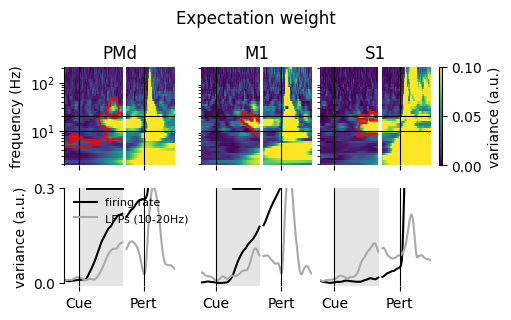

In [127]:
fig, axs_ = plt.subplots(2, len(rois)+1, sharex='col', figsize=(5, 3), gridspec_kw={"width_ratios": [80] * len(rois) + [2]}, constrained_layout=True)

axs = axs_[:, :-1]
ax_c = axs_[:, -1]

freq1, freq2 = 10, 20

vmin, vmax = 0, .1
color = [['darkred', 'navy'], ['lightcoral', 'lightblue']]
model = 'Expectation'
for r, roi in enumerate(rois):
    sig_lfp1 = np.load(os.path.join(gl.nhpDir, gl.pcmDir, f'significant_bf.lfp.Cue.{roi}.plan.npy'))
    sig_lfp1 = sig_lfp1[..., models.index(model)]
    lfp_tf1 = var_expl_lfp_plan.sel(roi=roi, time=slice(0, gl.cuePost-1), model=model).mean(dim='roi').values
    lfp_tf2 = var_expl_lfp_plan.sel(roi=roi, time=slice(gl.pertPre, None), model=model).mean(dim='roi').values
    lfp_t1 = var_expl_lfp_plan.sel(roi=roi, time=slice(0, gl.cuePost-1), model=model, freq=slice(freq1, freq2)).mean(dim=('roi', 'freq')).values
    lfp_t2 = var_expl_lfp_plan.sel(roi=roi, time=slice(gl.pertPre, None), model=model, freq=slice(freq1, freq2)).mean(dim=('roi', 'freq')).values
    h = axs[0, r].pcolormesh(t_cue, foi, lfp_tf1, vmin=vmin, vmax=vmax, cmap='viridis')
    axs[0, r].contour(t_cue, foi, sig_lfp1, levels=1, colors='r', linewidths=1)
    axs[0, r].pcolormesh(t_pert, foi, lfp_tf2, vmin=vmin, vmax=vmax, cmap='viridis')
    axs[0, r].set_yscale('log')
    axs[0, r].set_title(roi)
    axs[0, r].axhline(freq1, color='k', lw='.8')
    axs[0, r].axhline(freq2, color='k', lw='.8')
    axs[0, r].set_ylabel('frequency (Hz)') if r==0 else None
    sig_spk1 = np.load(os.path.join(gl.nhpDir, gl.pcmDir, f'significant_bf.spk.Cue.{roi}.plan.npy'))
    sig_spk1 = sig_spk1[..., models.index(model)].astype(float)
    sig_spk1[sig_spk1<1] = np.nan
    sig_spk1[sig_spk1==1] = .3
    axs[1, r].plot(t_cue, sig_spk1, color='k', lw=2)
    firing1 = var_expl_spk_plan.sel(roi=roi,time=slice(0, gl.cuePost-1), model=model).mean(dim='roi').values
    firing2 = var_expl_spk_plan.sel(roi=roi, time=slice(gl.pertPre, None), model=model).mean(dim='roi').values
    axs[1, r].plot(t_cue, firing1, color='k', label='firing rate')
    axs[1, r].plot(t_pert, firing2, color='k')
    axs[1, r].plot(t_cue, lfp_t1, color='darkgrey', label='LFPs (10-20Hz)')
    axs[1, r].plot(t_pert, lfp_t2, color='darkgrey')
    axs[1, r].axvspan(gl.cueIdx, gl.cuePost, color='grey', alpha=.2, lw=0)
    axs[1, r].set_ylim([-.01, .3])
    axs[1, r].set_yticks((0, .3))
    axs[1, r].spines['left'].set_bounds(0, .3)
    axs[1, r].set_ylabel('variance (a.u.)') if r==0 else None
    for i in range(2):
        axs[i, r].axvline(gl.cueIdx, color='k', lw='.8')
        axs[i, r].axvline(gl.pertIdx, color='k', lw='.8')
        axs[i, r].set_xticks([gl.cueIdx, gl.pertIdx])
        axs[i, r].set_xticklabels(['Cue', 'Pert'])
        axs[i, r].set_yticks([]) if r>0 else None
        axs[i, r].spines[['bottom', 'right', 'top']].set_visible(False) if r==0 else axs[i, r].spines[['bottom', 'right', 'top', 'left']].set_visible(False)

axs[1, 0].legend(frameon=False, ncol=1, fontsize=8, loc='upper left')

fig.colorbar(h, cax=ax_c[0], label='variance (a.u.)')
for ax in ax_c[1:]:
    ax.remove()

fig.suptitle(f'{model} weight', va='center')

plt.show()

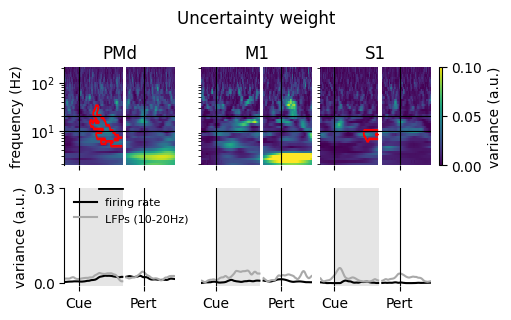

In [129]:
fig, axs_ = plt.subplots(2, len(rois)+1, sharex='col', figsize=(5, 3), gridspec_kw={"width_ratios": [80] * len(rois) + [2]}, constrained_layout=True)

axs = axs_[:, :-1]
ax_c = axs_[:, -1]

freq1, freq2 = 10, 20

vmin, vmax = 0, .1
color = [['darkred', 'navy'], ['lightcoral', 'lightblue']]
model = 'Uncertainty'
for r, roi in enumerate(rois):
    sig_lfp1 = np.load(os.path.join(gl.nhpDir, gl.pcmDir, f'significant_bf.lfp.Cue.{roi}.plan.npy'))
    sig_lfp1 = sig_lfp1[..., models.index(model)]
    lfp_tf1 = var_expl_lfp_plan.sel(roi=roi, time=slice(0, gl.cuePost-1), model=model).mean(dim='roi').values
    lfp_tf2 = var_expl_lfp_plan.sel(roi=roi, time=slice(gl.pertPre, None), model=model).mean(dim='roi').values
    lfp_t1 = var_expl_lfp_plan.sel(roi=roi, time=slice(0, gl.cuePost-1), model=model, freq=slice(freq1, freq2)).mean(dim=('roi', 'freq')).values
    lfp_t2 = var_expl_lfp_plan.sel(roi=roi, time=slice(gl.pertPre, None), model=model, freq=slice(freq1, freq2)).mean(dim=('roi', 'freq')).values
    h = axs[0, r].pcolormesh(t_cue, foi, lfp_tf1, vmin=vmin, vmax=vmax, cmap='viridis')
    axs[0, r].contour(t_cue, foi, sig_lfp1, levels=1, colors='r', linewidths=1)
    axs[0, r].pcolormesh(t_pert, foi, lfp_tf2, vmin=vmin, vmax=vmax, cmap='viridis')
    axs[0, r].set_yscale('log')
    axs[0, r].set_title(roi)
    axs[0, r].axhline(freq1, color='k', lw='.8')
    axs[0, r].axhline(freq2, color='k', lw='.8')
    axs[0, r].set_ylabel('frequency (Hz)') if r==0 else None
    sig_spk1 = np.load(os.path.join(gl.nhpDir, gl.pcmDir, f'significant_bf.spk.Cue.{roi}.plan.npy'))
    sig_spk1 = sig_spk1[..., models.index(model)].astype(float)
    sig_spk1[sig_spk1<1] = np.nan
    sig_spk1[sig_spk1==1] = .3
    axs[1, r].plot(t_cue, sig_spk1, color='k', lw=2)
    firing1 = var_expl_spk_plan.sel(roi=roi,time=slice(0, gl.cuePost-1), model=model).mean(dim='roi').values
    firing2 = var_expl_spk_plan.sel(roi=roi, time=slice(gl.pertPre, None), model=model).mean(dim='roi').values
    axs[1, r].plot(t_cue, firing1, color='k', label='firing rate')
    axs[1, r].plot(t_pert, firing2, color='k')
    axs[1, r].plot(t_cue, lfp_t1, color='darkgrey', label='LFPs (10-20Hz)')
    axs[1, r].plot(t_pert, lfp_t2, color='darkgrey')
    axs[1, r].axvspan(gl.cueIdx, gl.cuePost, color='grey', alpha=.2, lw=0)
    axs[1, r].set_ylim([-.01, .3])
    axs[1, r].set_yticks((0, .3))
    axs[1, r].spines['left'].set_bounds(0, .3)
    axs[1, r].set_ylabel('variance (a.u.)') if r==0 else None
    for i in range(2):
        axs[i, r].axvline(gl.cueIdx, color='k', lw='.8')
        axs[i, r].axvline(gl.pertIdx, color='k', lw='.8')
        axs[i, r].set_xticks([gl.cueIdx, gl.pertIdx])
        axs[i, r].set_xticklabels(['Cue', 'Pert'])
        axs[i, r].set_yticks([]) if r>0 else None
        axs[i, r].spines[['bottom', 'right', 'top']].set_visible(False) if r==0 else axs[i, r].spines[['bottom', 'right', 'top', 'left']].set_visible(False)

axs[1, 0].legend(frameon=False, ncol=1, fontsize=8, loc='upper left')

fig.colorbar(h, cax=ax_c[0], label='variance (a.u.)')
for ax in ax_c[1:]:
    ax.remove()

fig.suptitle(f'{model} weight', va='center')

plt.show()

In [139]:
# configurable lists
lfp_label = f"LFPs ({freq1}-{freq2} Hz)"

# pre-slice datasets once (avoids repeated indexing)
ds_lfp = var_expl_lfp_plan.sel(time=slice(gl.cueIdx, gl.cuePost), freq=slice(freq1, freq2))
ds_spk = var_expl_spk_plan.sel(time=slice(gl.cueIdx, gl.cuePost))

rows = []
sid = 0

for roi in rois:
    for model in models:
        # LFPs
        lfp_vals = ds_lfp.sel(roi=roi, model=model).mean(dim=("freq","time")).values.ravel()
        if lfp_vals.size:
            rows.append(pd.DataFrame({
                "var": lfp_vals,
                "roi": roi,
                "modality": lfp_label,
                "subject": np.arange(sid, sid + lfp_vals.size),
                "model": model
            }))
        # spikes
        spk_vals = ds_spk.sel(roi=roi, model=model).mean(dim=("time",)).values.ravel()
        if spk_vals.size:
            rows.append(pd.DataFrame({
                "var": spk_vals,
                "roi": roi,
                "modality": "spikes",
                "subject": np.arange(sid, sid + spk_vals.size),
                "model": model
            }))
    sid += lfp_vals.size

df = pd.concat(rows, ignore_index=True)

In [141]:
df_cue = df[df['model']=='Expectation']
df_unc = df[df['model']=='Uncertainty']
aov = pg.mixed_anova(dv="var", within="modality", between="roi", subject="subject", data=df_cue)

print(aov)

        Source      SS  DF1  DF2      MS       F   p-unc     np2     eps
0          roi 0.03391    2   32 0.01695 6.87791 0.00328 0.30064     NaN
1     modality 0.00939    1   32 0.00939 5.20501 0.02932 0.13990 1.00000
2  Interaction 0.03180    2   32 0.01590 8.81144 0.00089 0.35514     NaN


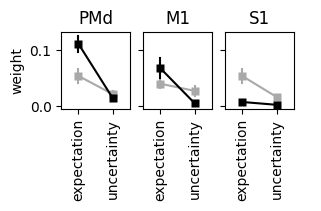

In [143]:
fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(3, 1))

for r, roi in enumerate(rois):
    ax = axs[r]
    sb.lineplot(data=df[df['roi']==roi], y='var', x='model', hue='modality', ax=ax, errorbar='se', marker='s', markeredgecolor='none', err_style='bars', palette=['darkgrey', 'k', ], legend=False)
    ax.set_xlim(-.5, 1.5)
    # ax.set_yticks([0, .12])
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['expectation', 'uncertainty'], rotation=90)
    # #ax.set_ylim(0, .15)
    # ax.spines[['top', 'right', 'bottom']].set_visible(False)
    # ax.spines['left'].set_bounds(0, .12)
    ax.set_xlabel(None)
    ax.set_ylabel('weight')
    ax.set_title(roi)

axs[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, frameon=False)

plt.show()